In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Helper functions for our metrics
def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def calculate_r_squared(y_true, y_pred):
    ss_residual = np.sum((y_true - y_pred)**2)
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_residual / ss_total)

# Generate random vectors X and Y (as requested in the prompt)
np.random.seed(42) # For reproducible results
X = np.random.rand(20) * 10
X.sort() # Sorting X is crucial for plotting lines properly
Y = np.random.rand(20) * 10 

# Create a dense X array for smooth plotting of polynomials later
X_smooth = np.linspace(X.min(), X.max(), 100)

--- Part A: Model Evaluation ---
Linear Fit -> MSE: 7.9089, R-Squared: 0.0181
Cubic Fit  -> MSE: 7.7578, R-Squared: 0.0368

Conclusion: The Cubic Polynomial is a better fit for this training data (higher R-Squared).


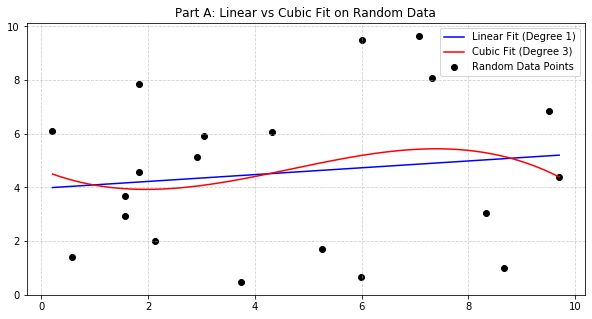

In [2]:
# 1. Linear Least Squares (Degree 1)
coeffs_linear = np.polyfit(X, Y, 1)
y_pred_linear = np.polyval(coeffs_linear, X)
mse_linear = calculate_mse(Y, y_pred_linear)
r2_linear = calculate_r_squared(Y, y_pred_linear)

# 2. Cubic Polynomial (Degree 3)
coeffs_cubic = np.polyfit(X, Y, 3)
y_pred_cubic = np.polyval(coeffs_cubic, X)
mse_cubic = calculate_mse(Y, y_pred_cubic)
r2_cubic = calculate_r_squared(Y, y_pred_cubic)

print("--- Part A: Model Evaluation ---")
print(f"Linear Fit -> MSE: {mse_linear:.4f}, R-Squared: {r2_linear:.4f}")
print(f"Cubic Fit  -> MSE: {mse_cubic:.4f}, R-Squared: {r2_cubic:.4f}\n")

# Evaluate which is better
if r2_cubic > r2_linear:
    print("Conclusion: The Cubic Polynomial is a better fit for this training data (higher R-Squared).")
else:
    print("Conclusion: The Linear model is a better fit for this training data.")

# Plotting
plt.figure(figsize=(10, 5))
plt.scatter(X, Y, color='black', label='Random Data Points')
plt.plot(X, y_pred_linear, color='blue', label='Linear Fit (Degree 1)')
# Using X_smooth for a curved cubic line
plt.plot(X_smooth, np.polyval(coeffs_cubic, X_smooth), color='red', label='Cubic Fit (Degree 3)')
plt.title('Part A: Linear vs Cubic Fit on Random Data')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

--- Part B: Cranking the Polynomial Degree ---
Degree  1 -> MSE: 7.9089 | R-Squared: 0.0181
Degree  2 -> MSE: 7.8910 | R-Squared: 0.0203
Degree  3 -> MSE: 7.7578 | R-Squared: 0.0368
Degree  5 -> MSE: 7.4687 | R-Squared: 0.0727
Degree  9 -> MSE: 4.2122 | R-Squared: 0.4770
Degree 15 -> MSE: 2.1124 | R-Squared: 0.7377


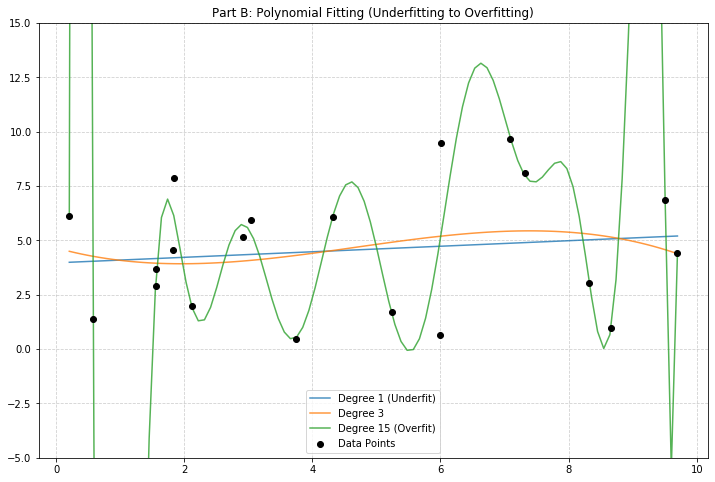

In [3]:
# Let's test degrees from 1 (underfit/baseline) up to 15 (severe overfit for 20 points)
degrees_to_test = [1, 2, 3, 5, 9, 15]

print("--- Part B: Cranking the Polynomial Degree ---")

plt.figure(figsize=(12, 8))
plt.scatter(X, Y, color='black', label='Data Points', zorder=10)

for degree in degrees_to_test:
    # Fit the polynomial
    coeffs = np.polyfit(X, Y, degree)
    
    # Predict to calculate metrics
    y_pred = np.polyval(coeffs, X)
    mse = calculate_mse(Y, y_pred)
    r2 = calculate_r_squared(Y, y_pred)
    
    print(f"Degree {degree:>2} -> MSE: {mse:.4f} | R-Squared: {r2:.4f}")
    
    # Plot only a few key degrees to keep the chart readable
    if degree in [1, 3, 15]:
        label = f'Degree {degree} (Underfit)' if degree == 1 else \
                f'Degree {degree} (Overfit)' if degree == 15 else f'Degree {degree}'
        plt.plot(X_smooth, np.polyval(coeffs, X_smooth), label=label, alpha=0.8)

plt.title('Part B: Polynomial Fitting (Underfitting to Overfitting)')
plt.ylim(-5, 15) # Constrain Y-axis because high-degree polynomials can shoot off to infinity
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [4]:
# We will use a Degree 3 (Cubic) fit for the Vandermonde demonstration
degree = 3

# 1. Generate the Vandermonde Matrix
# np.vander generates powers from N-1 down to 0. We want columns to be x^3, x^2, x^1, x^0
V = np.vander(X, degree + 1)

# 2. Solve the least squares problem: V * w = Y
# w contains the polynomial coefficients
w, residuals, rank, s = np.linalg.lstsq(V, Y, rcond=None)

# 3. Calculate predicted Y
Y_pred_vander = V.dot(w) # Matrix multiplication

# 4. Evaluate Metrics
mse_vander = calculate_mse(Y, Y_pred_vander)
r2_vander = calculate_r_squared(Y, Y_pred_vander)

print("--- Part C: Vandermonde Matrix (Degree 3) ---")
print("Coefficients calculated via Vandermonde:", w)
print(f"MSE: {mse_vander:.4f}")
print(f"R-Squared: {r2_vander:.4f}")

# Quick sanity check against Part A's cubic results
print("\n(Sanity Check: Does this match np.polyfit?)")
print(f"np.polyfit MSE was: {mse_cubic:.4f}")
print("Match!" if np.isclose(mse_vander, mse_cubic) else "Mismatch.")

--- Part C: Vandermonde Matrix (Degree 3) ---
Coefficients calculated via Vandermonde: [-0.01885627  0.26444842 -0.81854174  4.65440261]
MSE: 7.7578
R-Squared: 0.0368

(Sanity Check: Does this match np.polyfit?)
np.polyfit MSE was: 7.7578
Match!
